# Launch at Login for *existing* users (`e`) — interrogating the delivered model

**Goal:** understand and stress-test the producer's daily DAU curve before deciding whether to lift the `withheld` flag.
The curve was delivered 2026-09-10 as `launch-on-login-dau-forecasts.csv` (three-column daily contract) and ingested
as code `e` for the September cycle (seam 2026-09-09). It is **not applied** in the canonical build.

What the file claims, in the producer's own labels:

| stretch | label | basis |
|---|---|---|
| 2026-07-30 → 2026-09-08 | `actuals` | measured incremental DAU from the existing-users rollout, unsmoothed |
| 2026-09-09 → 2026-10-14 | `forecast` | producer's model on the current rollout population (~66K → 77K/day) |
| 2026-10-13, 2026-10-15 | `forecast` | steps at the **planned** rollout dates, not observed |
| 2026-10-15 → 2026-12-31 | `forecast` | full population, ~735K plateau, easing to 669K by Dec-31 |

Working notebook for an interactive session (2026-09-11). Sections are added as questions come up; comparison inputs
(experiment data, the September forecast, actuals) are wired in below as they arrive.


In [1]:
# [setup]
import os
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

CYCLE_DIR = Path("data-official/2026-09")
E_DIR = CYCLE_DIR / "launch_at_login_existing_users"
DELIVERED_CSV = E_DIR / "source_data" / "launch-on-login-dau-forecasts.csv"   # the producer's file, verbatim
BUILT_PARQUET = E_DIR / "launch_at_login_existing_users.2026-09-08.parquet"    # what the pipeline would load
SPEC_JSON = E_DIR / "launch_at_login_existing_users.json"
PLOTS_DIR = E_DIR / "plots"

# September canonical desktop build (e NOT applied) and its raw pull — for later comparisons
DESKTOP_FORECAST_PATH = (
    CYCLE_DIR / "desktop_g01_2026-09-09"
    / "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative"
    / "mozaic_daily_forecast.2026-09-09.ld-D.adj-ijlo.parquet"
)
DESKTOP_RAW_PULL = CYCLE_DIR / "desktop_rawpull_2026-09-09" / "mozaic_parts.raw.legacy.desktop.DAU.parquet"

# Dates the producer's curve hinges on
ROLLOUT_START = pd.Timestamp("2026-07-30")       # first measured day of the existing-users rollout
SEAM = pd.Timestamp("2026-09-09")                # forecast start; training through 2026-09-08
PLANNED_STEP_1 = pd.Timestamp("2026-10-13")      # planned rollout step (~66K -> ~77K/day)
PLANNED_STEP_2 = pd.Timestamp("2026-10-15")      # planned full-population rollout (~77K -> ~735K/day)
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")

COLOR_ACTUAL, COLOR_FORECAST, COLOR_MA = "#1f5fbf", "#d9822b", "#333333"

def thousands(v, _pos=None):
    """Tick formatter with precision chosen from magnitude: 45.3K, 736.9K, 1.20M."""
    a = abs(v)
    if a >= 1e6:
        return f"{v/1e6:.2f}M"
    if a >= 1e3:
        return f"{v/1e3:.1f}K"
    return f"{v:.0f}"

def mark_dates(ax, ymax_frac=0.97):
    """Vertical guides at the seam and the two planned rollout steps."""
    for d, label, ls in [(SEAM, "seam 09-09", "-"), (PLANNED_STEP_1, "planned step 10-13", ":"),
                         (PLANNED_STEP_2, "planned full rollout 10-15", "--")]:
        ax.axvline(d, color="grey", lw=1, ls=ls, alpha=0.8)
        ax.text(d, ax.get_ylim()[1] * ymax_frac, f" {label}", rotation=90, va="top", ha="left", fontsize=8, color="grey")

print(f"cwd: {os.getcwd()} | delivered: {DELIVERED_CSV} | seam {SEAM.date()}")


cwd: /Users/brendanwells/work/mozaic-daily | delivered: data-official/2026-09/launch_at_login_existing_users/source_data/launch-on-login-dau-forecasts.csv | seam 2026-09-09


In [2]:
# [load-raw]
raw = pd.read_csv(DELIVERED_CSV, parse_dates=["submission_date"]).rename(columns={"submission_date": "date"})
raw = raw.sort_values("date").set_index("date")
assert raw.index.is_unique and (raw.index.to_series().diff().dropna() == pd.Timedelta("1D")).all(), "gaps or dupes in delivered dates"
assert set(raw["type"]) == {"actuals", "forecast"}, raw["type"].unique()

raw["dau_ma28"] = raw["dau"].rolling(28).mean()
raw["dow"] = raw.index.day_name().str[:3]

actuals = raw[raw["type"] == "actuals"]
forecast = raw[raw["type"] == "forecast"]
print(f"rows {len(raw)} | actuals {actuals.index.min().date()}..{actuals.index.max().date()} ({len(actuals)}d) "
      f"| forecast {forecast.index.min().date()}..{forecast.index.max().date()} ({len(forecast)}d)")
print(f"last measured day {actuals.index.max().date()}: {actuals['dau'].iloc[-1]:,.0f} | first forecast day: {forecast['dau'].iloc[0]:,.0f} "
      f"(step {forecast['dau'].iloc[0] - actuals['dau'].iloc[-1]:+,.0f}; vs last-7d mean {actuals['dau'].iloc[-7:].mean():,.0f} -> {forecast['dau'].iloc[0] - actuals['dau'].iloc[-7:].mean():+,.0f})")
print(f"Dec-15 daily {raw.loc[MEASUREMENT_DATE, 'dau']:,.0f} | Dec-15 28d MA {raw.loc[MEASUREMENT_DATE, 'dau_ma28']:,.0f} | Dec-31 daily {raw['dau'].iloc[-1]:,.0f}")
raw.tail(3)


rows 155 | actuals 2026-07-30..2026-09-08 (41d) | forecast 2026-09-09..2026-12-31 (114d)
last measured day 2026-09-08: 45,331 | first forecast day: 66,141 (step +20,810; vs last-7d mean 40,074 -> +26,067)
Dec-15 daily 737,537 | Dec-15 28d MA 736,935 | Dec-31 daily 669,030


,type,dau,dau_ma28,dow
date,,,,
2026-12-29,forecast,684415.84,728432.000714,Tue
2026-12-30,forecast,678628.07,726315.914643,Wed
2026-12-31,forecast,669030.38,723852.862143,Thu


saved data-official/2026-09/launch_at_login_existing_users/plots/interrogate_raw_delivered_curve.png


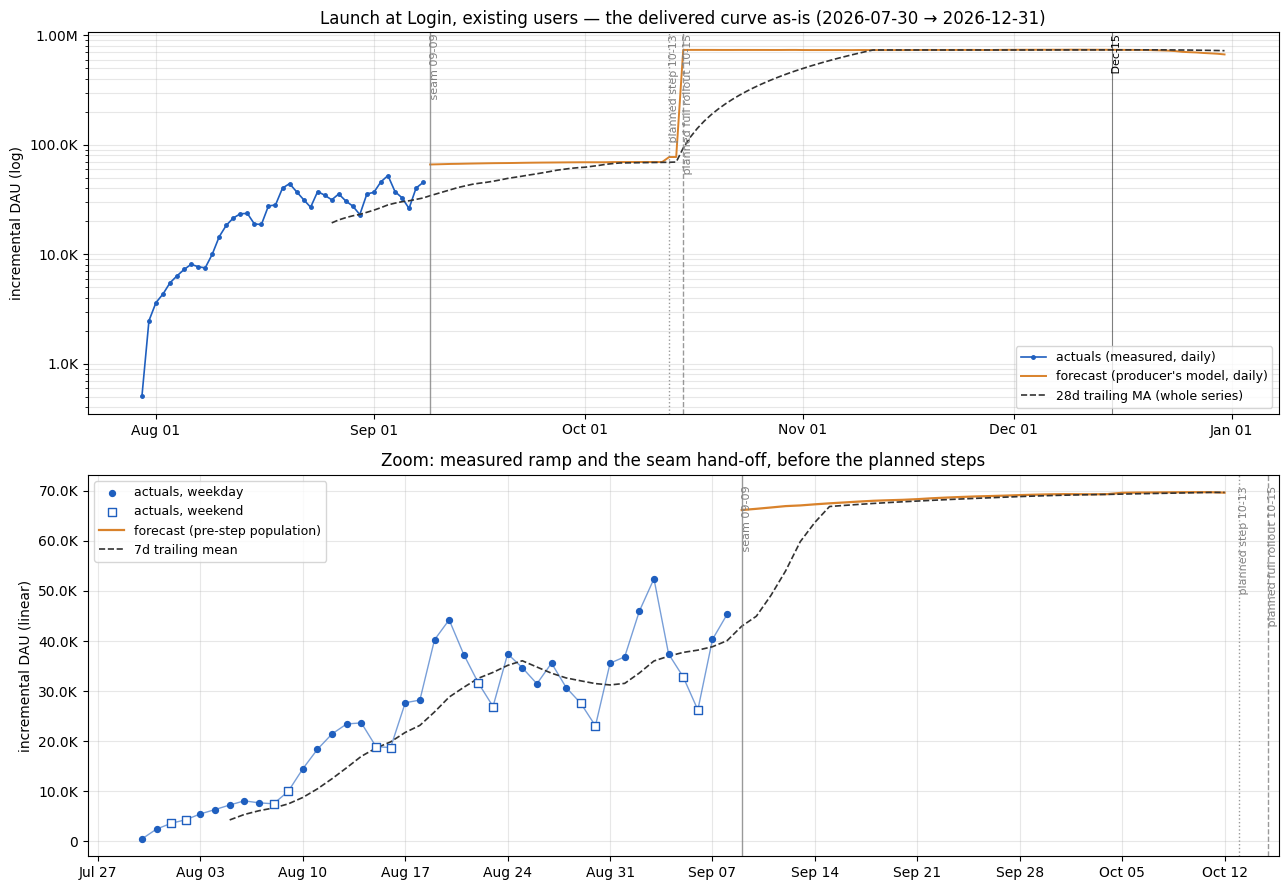

In [3]:
# [plot-raw]
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=False)

# Top: the whole delivered horizon, log scale so the 500 -> 735K span is readable
ax = axes[0]
ax.plot(actuals.index, actuals["dau"], color=COLOR_ACTUAL, lw=1.2, marker="o", ms=2.5, label="actuals (measured, daily)")
ax.plot(forecast.index, forecast["dau"], color=COLOR_FORECAST, lw=1.4, label="forecast (producer's model, daily)")
ax.plot(raw.index, raw["dau_ma28"], color=COLOR_MA, lw=1.2, ls="--", label="28d trailing MA (whole series)")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.yaxis.set_minor_formatter(mticker.NullFormatter())
ax.set_ylabel("incremental DAU (log)")
ax.set_title("Launch at Login, existing users — the delivered curve as-is (2026-07-30 → 2026-12-31)")
mark_dates(ax)
ax.axvline(MEASUREMENT_DATE, color="black", lw=0.8, alpha=0.5)
ax.text(MEASUREMENT_DATE, ax.get_ylim()[1] * 0.97, " Dec-15", rotation=90, va="top", fontsize=8)
ax.grid(alpha=0.3, which="both")
ax.legend(loc="lower right", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

# Bottom: the measured stretch plus the first forecast weeks, linear, weekday-coloured
ax = axes[1]
zoom_end = PLANNED_STEP_1 - pd.Timedelta("1D")
z = raw.loc[:zoom_end]
za, zf = z[z["type"] == "actuals"], z[z["type"] == "forecast"]
ax.plot(za.index, za["dau"], color=COLOR_ACTUAL, lw=1, alpha=0.6)
weekend = za.index.dayofweek >= 5
ax.scatter(za.index[~weekend], za["dau"][~weekend], color=COLOR_ACTUAL, s=18, label="actuals, weekday", zorder=3)
ax.scatter(za.index[weekend], za["dau"][weekend], color=COLOR_ACTUAL, s=28, marker="s", facecolors="white", label="actuals, weekend", zorder=3)
ax.plot(zf.index, zf["dau"], color=COLOR_FORECAST, lw=1.6, label="forecast (pre-step population)")
ax.plot(z.index, z["dau"].rolling(7).mean(), color=COLOR_MA, lw=1.2, ls="--", label="7d trailing mean")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.set_ylabel("incremental DAU (linear)")
ax.set_title("Zoom: measured ramp and the seam hand-off, before the planned steps")
mark_dates(ax)
ax.grid(alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

fig.tight_layout()
out = PLOTS_DIR / "interrogate_raw_delivered_curve.png"
fig.savefig(out, dpi=130)
print(f"saved {out}")
plt.show()


In [4]:
# [summary-table]
# Weekly means of the delivered daily values, so ramp rate and the size of each step are legible as numbers.
wk = raw["dau"].resample("W-SUN").agg(["mean", "min", "max"]).round(0)
wk["type"] = raw["type"].resample("W-SUN").agg(lambda s: "/".join(sorted(set(s))))
wk["wow_change"] = wk["mean"].diff().round(0)
wk.index = wk.index.date
pd.set_option("display.max_rows", 40)
display(wk)

steps = {
    "seam (last actual -> first forecast)": (actuals["dau"].iloc[-1], forecast["dau"].iloc[0]),
    "planned step 1 (10-12 -> 10-13)": (raw.loc[PLANNED_STEP_1 - pd.Timedelta("1D"), "dau"], raw.loc[PLANNED_STEP_1, "dau"]),
    "planned step 2 (10-14 -> 10-15)": (raw.loc[PLANNED_STEP_2 - pd.Timedelta("1D"), "dau"], raw.loc[PLANNED_STEP_2, "dau"]),
    "plateau peak -> Dec-31": (forecast["dau"].max(), forecast["dau"].iloc[-1]),
}
steps_df = pd.DataFrame([{"from": a, "to": b, "delta": b - a, "ratio": b / a if a else np.nan} for a, b in steps.values()], index=steps.keys()).round(2)
display(steps_df)


,mean,min,max,type,wow_change
2026-08-02,2736.0,504.0,4342.0,actuals,NaN
2026-08-09,7496.0,5498.0,9999.0,actuals,4760.0
2026-08-16,19880.0,14508.0,23658.0,actuals,12384.0
2026-08-23,33744.0,26926.0,44231.0,actuals,13864.0
2026-08-30,31501.0,23062.0,37439.0,actuals,-2243.0
2026-09-06,38184.0,26245.0,52425.0,actuals,6683.0
2026-09-13,59830.0,40324.0,67058.0,actuals/forecast,21646.0
2026-09-20,67784.0,67279.0,68175.0,forecast,7954.0
2026-09-27,68710.0,68308.0,69015.0,forecast,926.0
2026-10-04,69256.0,69117.0,69315.0,forecast,546.0


,from,to,delta,ratio
seam (last actual -> first forecast),45331.00,66140.82,20809.82,1.46
planned step 1 (10-12 -> 10-13),69607.96,77372.48,7764.52,1.11
planned step 2 (10-14 -> 10-15),77409.28,735584.34,658175.06,9.50
plateau peak -> Dec-31,739416.02,669030.38,-70385.64,0.90
